In [46]:
# %uv pip install pythae
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

In [47]:
from pythae.models import VQVAE, VQVAEConfig
from pythae.trainers import BaseTrainerConfig
from pythae.pipelines.training import TrainingPipeline
from pythae.models.nn.benchmarks.mnist.resnets import Encoder_ResNet_VQVAE_MNIST, Decoder_ResNet_VQVAE_MNIST
from vqvae_baseline_helpers import Encoder_VQVAE_PATCH, Decoder_VQVAE_PATCH

In [48]:
from dataclasses import dataclass
from typing_extensions import Self
from typing import Callable
import numpy as np
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from skimage.metrics import structural_similarity as ssim
from torchvision import transforms
from torch.utils.data import DataLoader
from torch import nn
import matplotlib.pyplot as plt
import torch.optim as optim
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence
from tqdm import tqdm
import torch

# %matplotlib widget

from typing import Optional
import matplotlib.pyplot as plt
import torch

from pileup_ml.detectors.pixels import PixelDetector, PixelModule
from pileup_ml.pixels.hits import PixelDigiEvent
from pileup_ml.pixels.patches import (
    PixelModulePatches, PixelEventPatches, _PixelEventGrid,
    event_hits_to_patches, module_patches_to_hits, event_patches_to_hits)
from pileup_ml.compression.metrics import compare_matching_hits, compare_hit_presence

from pileup_ml.compression.base import CompressedPixelEvent
from numpy import cov, trace, iscomplexobj
from scipy.linalg import sqrtm
from torch.utils.data import random_split
from torchmetrics.regression import MeanSquaredError
from matplotlib.gridspec import GridSpec
from pythae.models import AutoModel
import os

In [49]:
import torch
import torchvision.datasets as datasets

device = "cuda" if torch.cuda.is_available() else "cpu"

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [50]:
from helpers.model_tool import ModelTool, VQModelTool
from helpers.data_tool import CMSDataTool, \
                                CMSPlots, \
                                PixelPatchesDataset

In [51]:
# mnist_trainset = datasets.MNIST(root='data', train=True, download=True, transform=None)

# train_dataset = mnist_trainset.data[:-50000].reshape(-1, 1, 28, 28) / 255.
# eval_dataset = mnist_trainset.data[-10000:].reshape(-1, 1, 28, 28) / 255.

In [52]:
model_tool = ModelTool()
vq_model_tool = VQModelTool()
cms_data_tool = CMSDataTool()
cms_plots = CMSPlots()

In [53]:
EVENT_COUNT = 1
SELECTED_EVENTS = 1
PATCH_SIZE = 8

In [54]:
batch_size = 64

In [55]:
pixel_modules = PixelModule.read_json('/data/cern/pileup_ml/detid_info/detids_bpix.json', '/data/cern/pileup_ml/detid_info/detids_fpix.json')
pix_det = PixelDetector(pixel_modules)

events_train_all = PixelDigiEvent.read_root('/data/cern/pileup_ml/premixlib2024/0001.root', pix_det)
events_train = events_train_all[:EVENT_COUNT]

events_test_all = PixelDigiEvent.read_root('/data/cern/pileup_ml/premixlib2024/0002.root', pix_det)
events_test = events_test_all[:EVENT_COUNT]

100%|██████████| 1000/1000 [00:03<00:00, 281.22it/s]


In [56]:
event_train = events_train[:SELECTED_EVENTS][0]

In [57]:
patch_amount = cms_data_tool._get_patch_count(event_train)
total_hit_amount = len(event_train)

print(f"Total patch amount: {patch_amount}")
print(f"Total hits: {total_hit_amount}")

Total patch amount: 15857
Total hits: 48169


In [58]:
# Data preprocessing

transform = transforms.Compose([
    transforms.ToTensor(),
])

event_dataset = PixelPatchesDataset(event_train, PATCH_SIZE, transform, formatted=True)
dataset_size = len(event_dataset)

train_size = int(0.8 * dataset_size)
val_size = int(0.02 * dataset_size)
test_size = dataset_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    event_dataset,
    [train_size, val_size, test_size]
)


val_dataset_2 = PixelPatchesDataset(
    event_train, 
    PATCH_SIZE, 
    transform,
    val=True,
    shuffle_val=True
)

In [59]:
# Test check
a = next(iter(train_dataset))
a

DatasetOutput([('data',
                tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
                         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
                         [0.0000, 0.0000, 0.0000, 0.3843, 0.0000, 0.0000, 0.0000, 0.0000],
                         [0.0000, 0.0000, 0.0000, 0.3569, 0.0000, 0.0000, 0.0000, 0.0000],
                         [0.0000, 0.0000, 0.4941, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
                         [0.0000, 0.0000, 0.2471, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
                         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
                         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000]]])),
               ('label', 0)])

In [60]:
config = BaseTrainerConfig(
    output_dir='vqvae',
    learning_rate=1e-4,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    num_epochs=80, # Change this to train the model a bit more
)

model_config = VQVAEConfig(
    latent_dim=32,
    input_dim=(1, PATCH_SIZE, PATCH_SIZE),
    commitment_loss_factor=0.5,
    quantization_loss_factor=1.0,
    num_embeddings=256,
    use_ema=True,
    decay=0.99
)
model_config.patch_size = PATCH_SIZE

# TODO: fix errors The size of tensor a (1024) must match the size of tensor b (64) at
model = VQVAE(
    model_config=model_config,
    encoder=Encoder_VQVAE_PATCH(model_config), 
    decoder=Decoder_VQVAE_PATCH(model_config) 
)

In [61]:
# Model configs
# num_epochs = 80
# learning_rate = 1e-3

# optimizer = optim.Adam(
#     model.parameters(), 
#     lr=learning_rate, 
#     amsgrad=True
# )

In [62]:
pipeline = TrainingPipeline(
    training_config=config,
    model=model
)

In [63]:
pipeline(
    train_data=event_dataset,
    eval_data=val_dataset
)

Checking train dataset...
Checking eval dataset...
Using Base Trainer

Model passed sanity check !
Ready for training.

Created vqvae/VQVAE_training_2026-05-22_15-45-05. 
Training config, checkpoints and final model will be saved here.

Training params:
 - max_epochs: 80
 - per_device_train_batch_size: 64
 - per_device_eval_batch_size: 64
 - checkpoint saving every: None
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)
Scheduler: None

Successfully launched training !



Training of epoch 1/80:   0%|          | 0/248 [00:00<?, ?batch/s]

Eval of epoch 1/80:   0%|          | 0/5 [00:00<?, ?batch/s]

--------------------------------------------------------------------------
Train loss: 1.8351
Eval loss: 0.5091
--------------------------------------------------------------------------


Training of epoch 2/80:   0%|          | 0/248 [00:00<?, ?batch/s]

...

Eval of epoch 79/80:   0%|          | 0/5 [00:00<?, ?batch/s]

--------------------------------------------------------------------------
Train loss: 0.0521
Eval loss: 0.045
--------------------------------------------------------------------------


Training of epoch 80/80:   0%|          | 0/248 [00:00<?, ?batch/s]

Eval of epoch 80/80:   0%|          | 0/5 [00:00<?, ?batch/s]

--------------------------------------------------------------------------
Train loss: 0.051
Eval loss: 0.0455
--------------------------------------------------------------------------
Training ended!
Saved final model in vqvae/VQVAE_training_2026-05-22_15-45-05/final_model


In [64]:
last_training = sorted(os.listdir('vqvae'))[-1]
trained_model = AutoModel.load_from_folder(
    os.path.join('vqvae', last_training, 'final_model')
).to(device)

In [65]:
trained_model.decoder

Decoder_VQVAE_PATCH(
  (layers): ModuleList(
    (0): ConvTranspose2d(32, 128, kernel_size=(1, 1), stride=(1, 1))
    (1): ConvTranspose2d(128, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (2): Sequential(
      (0): ResBlock(
        (conv_block): Sequential(
          (0): ReLU()
          (1): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (2): ReLU()
          (3): Conv2d(32, 128, kernel_size=(1, 1), stride=(1, 1))
        )
      )
      (1): ResBlock(
        (conv_block): Sequential(
          (0): ReLU()
          (1): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (2): ReLU()
          (3): Conv2d(32, 128, kernel_size=(1, 1), stride=(1, 1))
        )
      )
      (2): ReLU()
    )
    (3): Sequential(
      (0): ConvTranspose2d(128, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
      (1): ReLU()
    )
    (4): Sequential(
      (0): ConvTranspose2d

In [66]:
model_tool._display_gradients(trained_model)

Showing model gradients


In [67]:
# val_dataset_ = list(iter(val_dataset))[:10]
batch = torch.stack(list(iter(val_dataset_2))[:10]).to(device)

# interpolations = trained_model.interpolate(batch[:5].to(device), batch[5:10].to(device), granularity=10).detach().cpu()
patches_encodings = []
patches_before = []
patches_after = []
vq_vae_loss = []


for patch in val_dataset_2:
    patch = patch.to(device)
    patch_flt = patch[0].to(device)
    
    patches_before.append(
        model_tool._tensor_to_numpy(patch_flt)
    )
    
    patch_input = {
        "data" : patch.unsqueeze(0)
    }
    
    (
        result
    ) = trained_model(patch_input)
    
    
    encodings = result.quantized_indices
    encodings = encodings.float()
    
    patches_encodings.append(
        model_tool._tensor_to_numpy(
            encodings
        )[0][0]
    )
    
    recon_x = result.recon_x.to(device)
    patches_after.append(
        model_tool._tensor_to_numpy(result.recon_x[0]).reshape(
            PATCH_SIZE,
            PATCH_SIZE
        )
    )
     
    

In [68]:
patches_before[0].shape

(8, 8)

In [69]:
batch[0][0].shape

torch.Size([8, 8])

In [70]:
# len(patches_before_before)
len(patches_before)

15

In [71]:
# len(patches_before_after)
patches_after[0].shape

(8, 8)

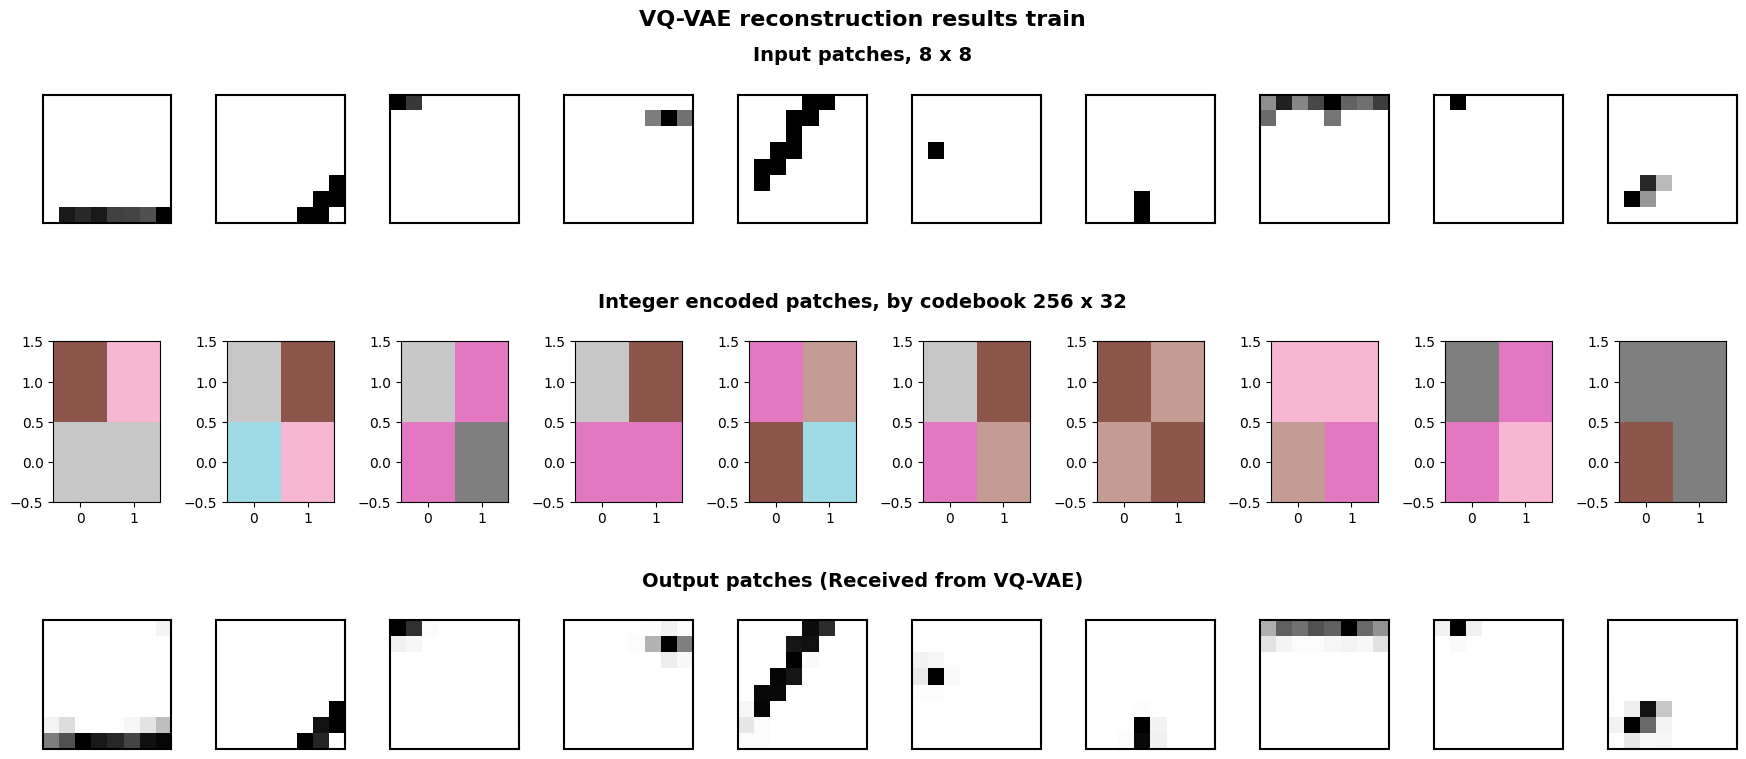

In [72]:
DISPLAY_LIMIT = 10

patch_rows = [
    (patches_before[:DISPLAY_LIMIT], "Input patches, 8 x 8"),
    
    # TODO: added different colors for each codebook index
    (
        patches_encodings[:DISPLAY_LIMIT], 
        f"Integer encoded patches, by codebook"
        f" {model_config.num_embeddings} x {model_config.latent_dim}"
    ),
    (patches_after[:DISPLAY_LIMIT], "Output patches (Received from VQ-VAE)")
]

cms_plots.plot_patches(
    patch_rows, 
    "VQ-VAE reconstruction results train",
    include_embeddings=True,
    embeddings=model_config.num_embeddings
)

In [ ]:
# cms_plots.plot_curve(
#     y_values=vq_vae_loss,
#     x_values=list(range(0, len(model_config.num_epochs))),
#     y_title="VQ loss",
#     title="VQVAE loss accross epochs",
#     x_label="patch"
# )

AttributeError: 'VQVAEConfig' object has no attribute 'num_epochs'

In [ ]:
# vqvq_model_perplexity

[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

In [ ]:
# import matplotlib.pyplot as plt

# show reconstructions
# fig, axes = plt.subplots(nrows=5, ncols=5, figsize=(8, 8))

# for i in range(5):
#     for j in range(5):
#         axes[i][j].imshow(reconstructions[j][0], cmap='gist_yarg', origin='lower')
#         axes[i][j].axis('off')
# plt.tight_layout(pad=0.)

In [ ]:
# # show the true data
# fig, axes = plt.subplots(nrows=5, ncols=5, figsize=(8, 8))

# for i in range(5):
#     for j in range(5):
#         axes[i][j].imshow(val_dataset[j].data.cpu().squeeze(0), cmap='gist_yarg', origin='lower')
#         axes[i][j].axis('off')
# plt.tight_layout(pad=0.)

In [ ]:
# interpolations = trained_model.interpolate(eval_dataset[:5].to(device), eval_dataset[5:10].to(device), granularity=10).detach().cpu()

In [ ]:
# # show interpolations
# fig, axes = plt.subplots(nrows=5, ncols=10, figsize=(10, 5))

# for i in range(5):
#     for j in range(10):
#         axes[i][j].imshow(interpolations[i, j].cpu().squeeze(0), cmap='gist_yarg', origin='lower')
#         axes[i][j].axis('off')
# plt.tight_layout(pad=0.)